In [43]:
import base64
from io import BytesIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/biratpoudel/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [32]:
def load_data(file_path):
    df = pd.read_csv(file_path)
    print(f"Loaded {df.shape[0]} customer records with {df.shape[1]} features")
    return df

In [33]:
def preprocess_data(df):
    # Handle missing numerical features values 
    df['Booking_Frequency'] = df['Booking_Frequency'].fillna(df['Booking_Frequency'].median())
    df['Avg_Spending'] = df['Avg_Spending'].fillna(df['Avg_Spending'].median())

    # Handle missing categorical features values
    df['Preferred_Service'] = df['Preferred_Service'].fillna(df['Preferred_Service'].mode()[0])

    # Handle missing text values
    df['Review_Text'] = df['Review_Text'].fillna("[No Review]")

    # Calculate recency (days since last activity)
    current_date = datetime.now()
    df['Last_Activity'] = pd.to_datetime(df['Last_Activity'])
    df['Recency'] = (current_date - df['Last_Activity']).dt.days

    sia = SentimentIntensityAnalyzer()
    df['Sentiment_Score'] = df['Review_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

    return df

In [34]:
# Create RFM features (Recency, Frequency, Monetary)
def create_features(df):
    df['recency_score'] = pd.qcut(df['Recency'], 5, labels=[5, 4, 3, 2, 1])
    df['frequency_score'] = pd.qcut(df['Booking_Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    df['monetary_score'] = pd.qcut(df['Avg_Spending'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    
    df['recency_score'] = pd.to_numeric(df['recency_score'])
    df['frequency_score'] = pd.to_numeric(df['frequency_score'])
    df['monetary_score'] = pd.to_numeric(df['monetary_score'])
    
    df['RFM_Score'] = df['recency_score'] + df['frequency_score'] + df['monetary_score']
    
    service_dummies = pd.get_dummies(df['Preferred_Service'], prefix='Service')
    df = pd.concat([df, service_dummies], axis=1)
    
    return df

In [41]:
def segment_customers(df):
    features = df[['recency_score', 'frequency_score', 'monetary_score', 'Sentiment_Score']]
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    n_samples = features_scaled.shape[0]
    max_clusters = min(10, n_samples)
    
    wcss = []
    for i in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
        kmeans.fit(features_scaled)
        wcss.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='-')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.grid(True)
    plt.savefig('elbow_curve.png')
    
    optimal_k = 2
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(features_scaled)
    
    cluster_analysis = df.groupby('Cluster').agg({
        'Recency': 'mean',
        'Booking_Frequency': 'mean',
        'Avg_Spending': 'mean',
        'Sentiment_Score': 'mean',
        'RFM_Score': 'mean',
        'Customer_ID': 'count'
    }).sort_values('RFM_Score', ascending=False)
    
    segment_names = ['High-Value Loyal', 'Regular Customer', 'At-Risk', 'New/Potential']
    cluster_mapping = {}
    
    for i in range(optimal_k):
        if i < len(cluster_analysis.index):
            cluster_mapping[cluster_analysis.index[i]] = segment_names[i]
    
    df['Segment'] = df['Cluster'].map(cluster_mapping)
    
    return df

In [36]:
def generate_insights(df):
    segment_metrics = df.groupby('Segment').agg({
        'Recency': 'mean',
        'Booking_Frequency': 'mean',
        'Avg_Spending': 'mean',
        'Sentiment_Score': 'mean',
        'Customer_ID': 'count'
    })
    
    segment_metrics['Total_Revenue'] = segment_metrics['Customer_ID'] * segment_metrics['Booking_Frequency'] * segment_metrics['Avg_Spending']
    segment_metrics['Revenue_Percentage'] = segment_metrics['Total_Revenue'] / segment_metrics['Total_Revenue'].sum() * 100
    
    service_preferences = df.groupby('Segment')['Preferred_Service'].value_counts().unstack().fillna(0)
    service_preferences_pct = service_preferences.div(service_preferences.sum(axis=1), axis=0) * 100
    
    recommendations = {
        'High-Value Loyal': [
            "Implement a premium tier membership with exclusive benefits",
            "Create a referral program with incentives for bringing new customers",
            "Send personalized thank you messages and birthday offers",
            "Provide early access to new services and special events"
        ],
        'Regular Customer': [
            "Implement a loyalty points program to encourage more frequent bookings",
            "Cross-sell complementary services based on past preferences",
            "Send seasonal promotions and package deals",
            "Request feedback for service improvement"
        ],
        'At-Risk': [
            "Launch a re-engagement email campaign with personalized discounts",
            "Send satisfaction surveys to identify pain points",
            "Offer 'We miss you' promotions with limited-time offers",
            "Improve services based on negative review analysis"
        ],
        'New/Potential': [
            "Create a welcome package with trial offers",
            "Develop educational content about service benefits",
            "Offer first-time booking incentives",
            "Simplify the booking process to reduce friction"
        ]
    }
    
    return segment_metrics, service_preferences_pct, recommendations

In [44]:
def create_visualizations(df, segment_metrics, service_preferences):
    plot_images = {}
    
    # 1. Customer Segment Distribution
    plt.figure(figsize=(12, 6))
    sns.countplot(x='Segment', data=df, palette='viridis')
    plt.title('Customer Segment Distribution')
    
    buffer = BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    plot_images['segment_distribution'] = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    
    # 2. RFM Score by Segment
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Segment', y='RFM_Score', data=df, palette='viridis')
    plt.title('RFM Score Distribution by Customer Segment')
    
    buffer = BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    plot_images['rfm_by_segment'] = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    
    # 3. Revenue Contribution by Segment
    plt.figure(figsize=(10, 6))
    segment_metrics['Revenue_Percentage'].plot(kind='pie', autopct='%1.1f%%', 
                                             startangle=90, figsize=(10, 6),
                                             colors=sns.color_palette('viridis', len(segment_metrics)))
    plt.title('Revenue Contribution by Customer Segment')
    plt.ylabel('')
    
    buffer = BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    plot_images['revenue_contribution'] = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    
    # 4. Service Preferences by Segment
    plt.figure(figsize=(14, 8))
    service_preferences.plot(kind='bar', stacked=True)
    plt.title('Service Preferences by Customer Segment')
    plt.xlabel('Customer Segment')
    plt.ylabel('Percentage')
    plt.legend(title='Service Type')
    
    buffer = BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    plot_images['service_preferences'] = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    
    # 5. Sentiment Analysis by Segment
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Segment', y='Sentiment_Score', data=df, palette='viridis')
    plt.title('Customer Sentiment by Segment')
    
    buffer = BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    plot_images['sentiment_by_segment'] = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    
    return plot_images

def generate_report(df, segment_metrics, service_preferences, recommendations):
    plot_images = create_visualizations(df, segment_metrics, service_preferences)
    
    with open('customer_analysis.md', 'w') as f:
        f.write("# Customer Behavior Analysis Report\n\n")
        
        f.write("## Executive Summary\n\n")
        f.write("This report presents a comprehensive analysis of customer behavior patterns ")
        f.write("based on booking frequency, spending patterns, service preferences, and sentiment analysis. ")
        f.write("We have identified distinct customer segments and provided targeted recommendations for each.\n\n")
        
        f.write("## Customer Segmentation\n\n")
        
        f.write("### Customer Segment Distribution\n\n")
        f.write(f"![Customer Segment Distribution](data:image/png;base64,{plot_images['segment_distribution']})\n\n")
        
        f.write("We identified the following customer segments:\n\n")
        
        for segment in segment_metrics.index:
            f.write(f"### {segment} Customers\n")
            f.write(f"- **Count:** {segment_metrics.loc[segment, 'Customer_ID']:.0f}\n")
            f.write(f"- **Average Spending:** ${segment_metrics.loc[segment, 'Avg_Spending']:.2f}\n")
            f.write(f"- **Booking Frequency:** {segment_metrics.loc[segment, 'Booking_Frequency']:.2f} times\n")
            f.write(f"- **Recency:** {segment_metrics.loc[segment, 'Recency']:.1f} days since last activity\n")
            f.write(f"- **Sentiment Score:** {segment_metrics.loc[segment, 'Sentiment_Score']:.2f}\n")
            f.write(f"- **Revenue Contribution:** {segment_metrics.loc[segment, 'Revenue_Percentage']:.1f}%\n\n")
        
        f.write("### RFM Score Distribution by Segment\n\n")
        f.write(f"![RFM Score Distribution](data:image/png;base64,{plot_images['rfm_by_segment']})\n\n")
        
        f.write("### Revenue Contribution by Segment\n\n")
        f.write(f"![Revenue Contribution](data:image/png;base64,{plot_images['revenue_contribution']})\n\n")
        
        f.write("### Service Preferences by Segment\n\n")
        f.write(f"![Service Preferences](data:image/png;base64,{plot_images['service_preferences']})\n\n")
        
        f.write("### Customer Sentiment by Segment\n\n")
        f.write(f"![Sentiment Analysis](data:image/png;base64,{plot_images['sentiment_by_segment']})\n\n")
        
        f.write("## Key Insights\n\n")
        f.write("1. **High-Value Loyal Customers** represent ")
        f.write(f"{segment_metrics.loc['High-Value Loyal', 'Customer_ID'] / df.shape[0] * 100:.1f}% of our customer base ")
        f.write(f"but contribute {segment_metrics.loc['High-Value Loyal', 'Revenue_Percentage']:.1f}% of revenue.\n")
        
        if 'At-Risk' in segment_metrics.index:
            f.write("2. **At-Risk Customers** show the lowest sentiment scores and haven't engaged with our services recently.\n")
        
        f.write(f"{'3' if 'At-Risk' in segment_metrics.index else '2'}. **Service Preferences** vary significantly between segments, with High-Value customers preferring premium services.\n")
        
        if 'New/Potential' in segment_metrics.index:
            f.write(f"{'4' if 'At-Risk' in segment_metrics.index else '3'}. **New/Potential Customers** show interest but haven't established a regular booking pattern yet.\n\n")
        
        f.write("\n## Recommendations\n\n")
        
        for segment, recs in recommendations.items():
            if segment in segment_metrics.index:
                f.write(f"### For {segment} Customers:\n")
                for i, rec in enumerate(recs, 1):
                    f.write(f"{i}. {rec}\n")
                f.write("\n")
        
        f.write("## Next Steps\n\n")
        f.write("1. Implement targeted marketing campaigns for each customer segment\n")
        f.write("2. Develop a customer loyalty program based on RFM analysis\n")
        f.write("3. Address service issues identified through sentiment analysis\n")
        f.write("4. Monitor customer migration between segments quarterly\n")
        f.write("5. Set up automated alerts for at-risk customer identification\n")

In [47]:
def main():
    df = load_data('/Users/biratpoudel/Desktop/blys/customer_data.csv')
    df = preprocess_data(df)
    df = create_features(df)
    df = segment_customers(df)
    segment_metrics, service_preferences, recommendations = generate_insights(df)
    generate_report(df, segment_metrics, service_preferences, recommendations)
    print("Analysis complete. Report generated as 'customer_analysis.md'")

Loaded 3 customer records with 6 features
Analysis complete. Report generated as 'customer_analysis.md'


/var/folders/nv/sqtq62zn71x7ptnjf41sd2200000gn/T/ipykernel_4961/2350472452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=df, palette='viridis')
/var/folders/nv/sqtq62zn71x7ptnjf41sd2200000gn/T/ipykernel_4961/2350472452.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='RFM_Score', data=df, palette='viridis')
/var/folders/nv/sqtq62zn71x7ptnjf41sd2200000gn/T/ipykernel_4961/2350472452.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='Sentiment_Score', data=df, palette='viridis')


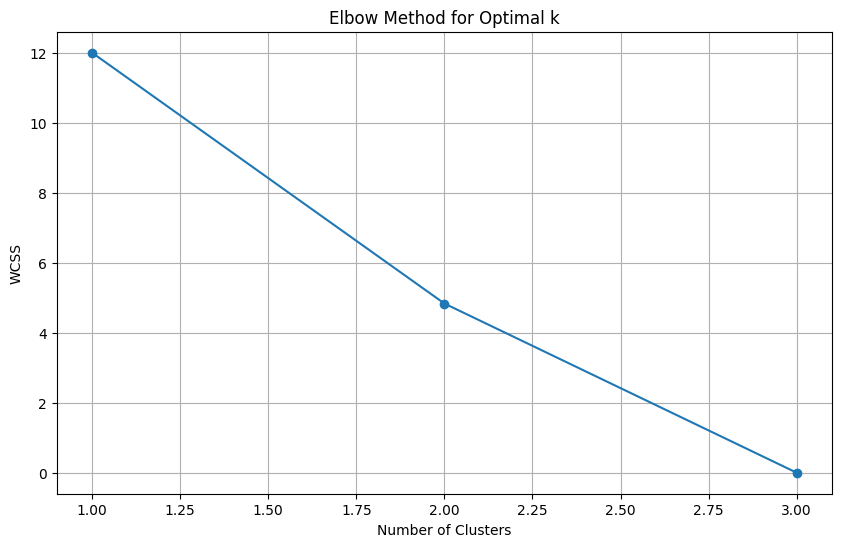

<Figure size 1400x800 with 0 Axes>

In [49]:
if __name__ == "__main__":
    main()